In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator as idg
from keras.layers import Dense, Input, Dropout, Flatten, BatchNormalization
from keras.layers import MaxPooling2D, Conv2D
from keras.models import Sequential
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Extra Not in Use
import cv2
from cv2 import resize
from tensorflow.keras.utils import image_dataset_from_directory as idfd
import pickle
import random
import os
import zipfile
import seaborn as sns
import statistics as st
import matplotlib.image as mpimg
import copy 



### Training Data

In [2]:
# 1. Load Training Data
train_path = r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\X Ray Dataset\chest_xray\train"

datagen = idg(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_path,
    batch_size=32,
    target_size=(100, 100),
    class_mode='binary',
    color_mode='grayscale',
    shuffle=True
)

print(train_data.class_indices)
images, labels = next(train_data)
print(images.shape)

# # 2. Alternative (Manual loading – more control)
# data = []
# labels = []

# path = r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\X Ray Dataset\chest_xray\train"

# for category in ["NORMAL", "PNEUMONIA"]:
#     folder = os.path.join(path, category)
#     label = 0 if category == "NORMAL" else 1
    
#     for img in os.listdir(folder):
#         img_path = os.path.join(folder, img)
#         image = cv2.imread(img_path)
#         image = cv2.resize(image, (100, 100))
        
#         data.append(image)
#         labels.append(label)

# X = np.array(data) / 255.0
# y = np.array(labels)

# # 3. Load Data From Tensor Flow Library Image Dataset From Directory
# train_ds = idfd(
#     r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\X Ray Dataset\chest_xray\train",
#     image_size=(100, 100),
#     batch_size=32
# )

# # Normalize
# train_ds = train_ds.map(lambda x, y: (x / 255.0, y))



Found 5226 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}
(32, 100, 100, 1)


### Show Sample

In [ ]:
# 1.
print('1 One Photo Sample :\n')
plt.imshow(images[0])
plt.title(labels[0])
plt.axis('off')
plt.show()

# 2.
print('5 Sample Images : \n')
# Plot Subplots
fig, axes = plt.subplots(1, 5, figsize=(15,5))
for i in range(len(axes)):
    axes[i].imshow(images[i])
    axes[i].set_title(labels[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# 3.
print('1 Batch Sample : \n')
# Plot Subplots
fig, axes = plt.subplots(8, 4, figsize=(15, 25))
axes = axes.flatten()
for i in range(len(axes)):
    axes[i].imshow(images[i])
    axes[i].set_title(labels[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [3]:
# Split Data In X and Y Variable
x = []
y = []

for _ in range(len(train_data)):
    images, labels = next(train_data)
    x.append(images)
    y.append(labels)

print('Data Split is Completed')
print('Length of X : ', len(x))
print('Length of Y : ', len(y))

Data Split is Completed
Length of X :  164
Length of Y :  164


In [4]:
# All Data In One By Numpy
x_array = np.concatenate(x, axis=0)
y_array = np.concatenate(y, axis=0)
print("** Data Concatination Completed **")

# NOW you can check the shape of the entire dataset!
print('\n'*1)
print("Shape of all images:", x_array.shape)
print("Shape of all labels:", y_array.shape)

# Check Length OF Data Set 
print(len(x_array))
print(len(y_array))

** Data Concatination Completed **
5226
5226


### Validating Data

In [5]:
val_path = r"D:\COURSE\DATA SCIENCE FULL COURSE BY UDEMY\SECTION 8 Deep Learning\Deep Learning - Resources-20260311T130352Z-3-001\Deep Learning - Resources\X Ray Dataset\chest_xray\val"

val_data = datagen.flow_from_directory(
    val_path,
    batch_size=16,
    target_size=(100, 100),
    class_mode='binary',
    color_mode='grayscale',
    shuffle=True
)

print(val_data.class_indices)

images, labels = next(val_data)
print(images.shape)

Found 16 images belonging to 2 classes.
{'NORMAL': 0, 'PNEUMONIA': 1}
(16, 100, 100, 1)


Show Sample Of One Image :


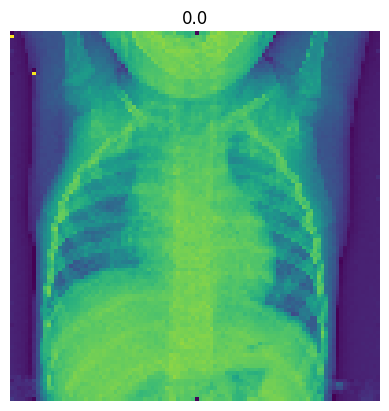

Show Sample Of Five Image :


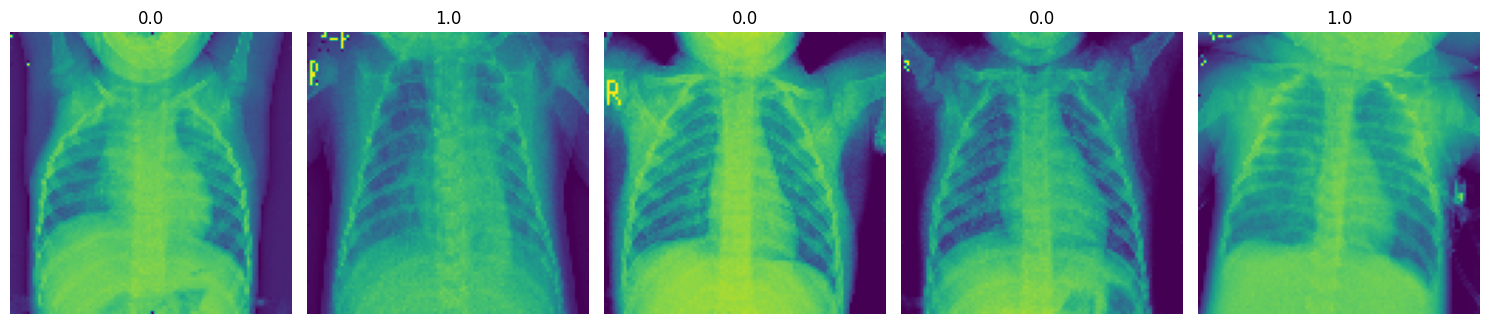

Show Sample Of One Batch :


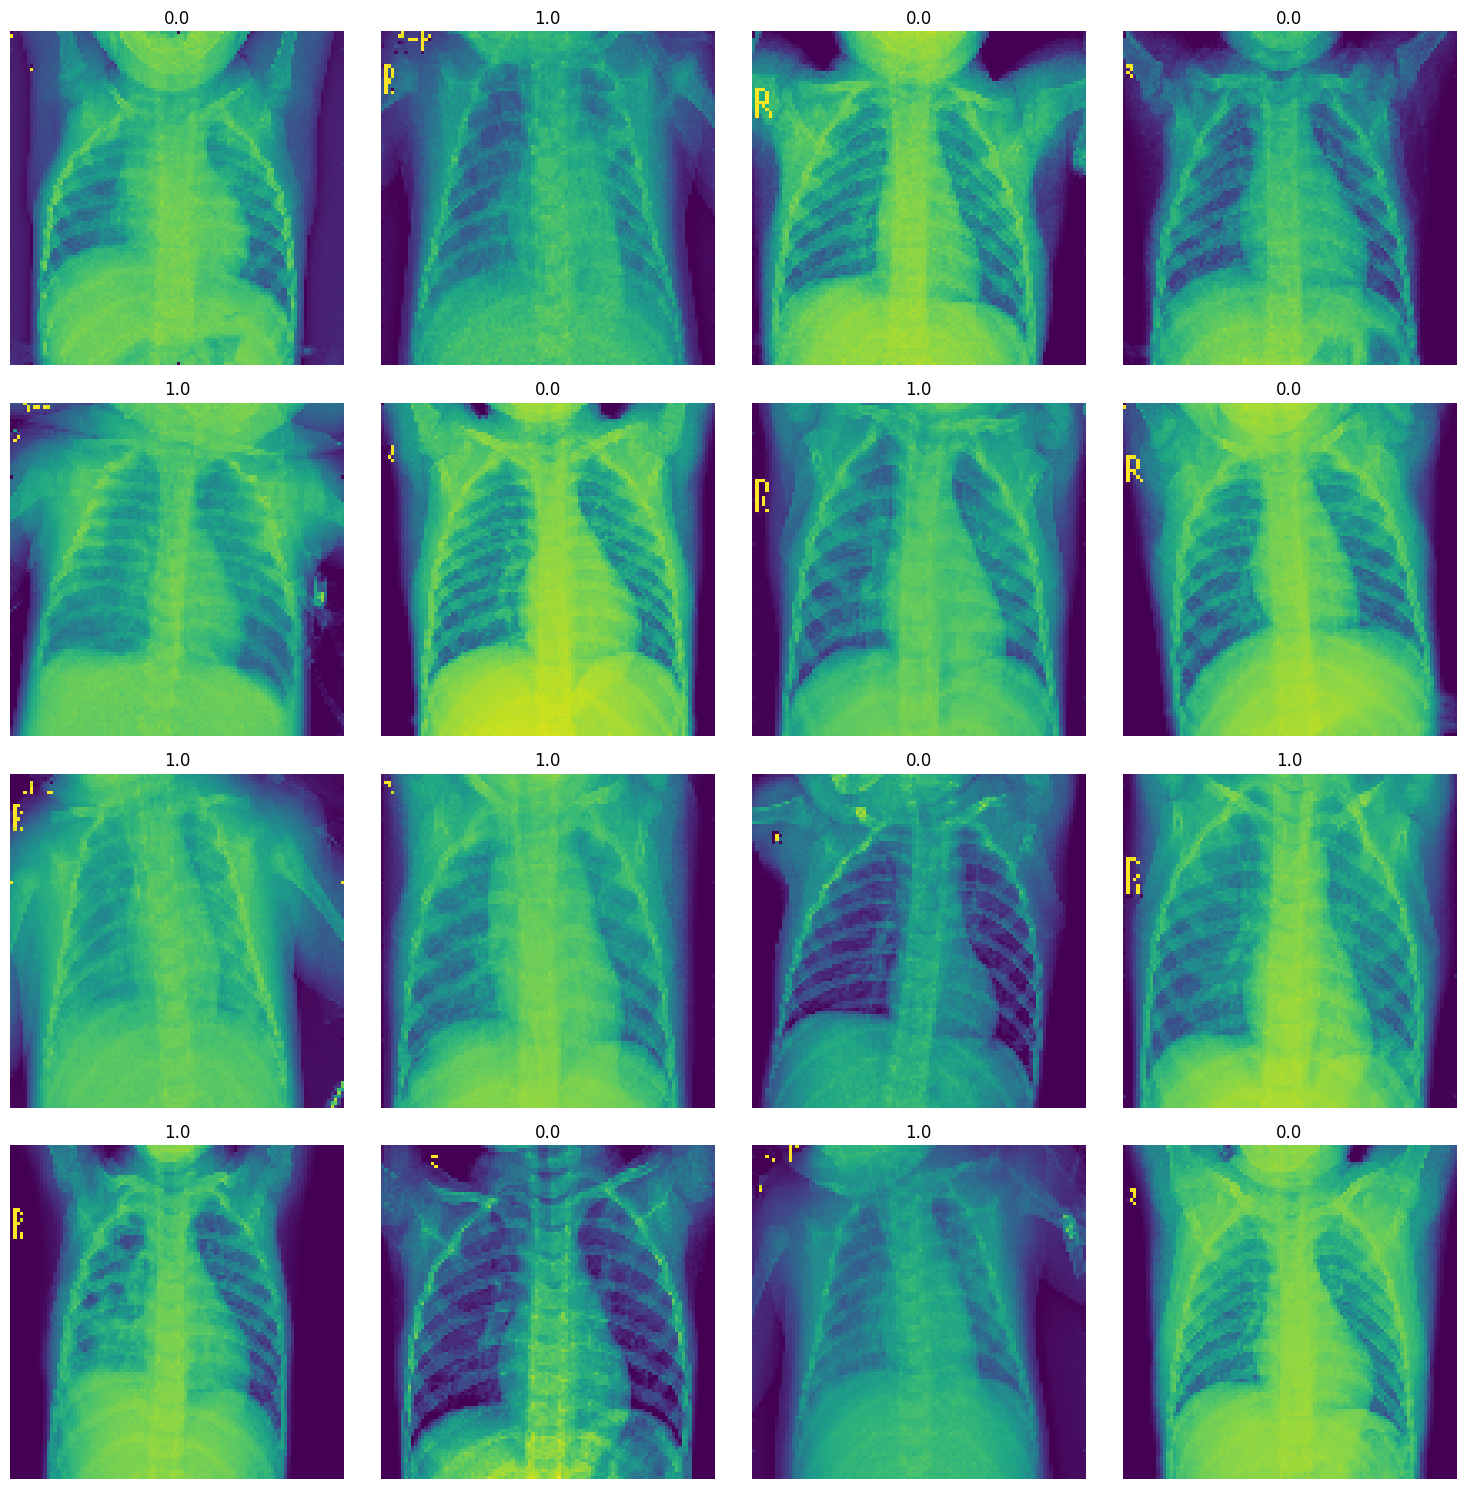

In [6]:
print('Show Sample Of One Image :')
plt.imshow(images[0])
plt.title(labels[0])
plt.axis('off')
plt.show()

print('Show Sample Of Five Image :')
# Plot Subplots
fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for i in range(len(axes)):
    axes[i].imshow(images[i])
    axes[i].set_title(labels[i])
    axes[i].axis('off')
plt.tight_layout()
plt.show()


print('Show Sample Of One Batch :')
# Plot Subplots
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
axes = axes.flatten()
for i in range(len(axes)):
    axes[i].imshow(images[i])
    axes[i].set_title(labels[i])
    axes[i].axis('off')

plt.tight_layout()
plt.show()

In [7]:
# Split Data In X and Y 
x_val = []
y_val = []

for _ in range(len(val_data)):
    images, labels = next(val_data)
    x_val.append(images)
    y_val.append(labels)

print('**Split Is Done**')
print('Length of X :', len(x_val))
print('Length of Y :', len(y_val))

**Split Is Done**
Length of X : 1
Length of Y : 1


In [8]:
# All Data In One Array
x_val_array = np.concatenate(x_val, axis=0)
y_val_array = np.concatenate(y_val, axis=0)
print('Length of X Array : ', len(x_val_array))
print('Length of Y Array : ', len(y_val_array))


Length of X Array :  16
Length of Y Array :  16


## Actual Model

In [65]:
model = Sequential()

model.add(Input(shape=(100, 100, 1)))

model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(units=128, kernel_initializer='he_uniform', bias_initializer='zeros', activation='relu'))
model.add(Dense(units=64, kernel_initializer='he_uniform', bias_initializer='zeros', activation='relu'))
model.add(Dense(units=1, kernel_initializer='he_uniform', bias_initializer='zeros', activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

hist = model.fit(train_data, validation_data = val_data, epochs=64)

Epoch 1/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 62s 361ms/step - accuracy: 0.9101 - loss: 0.2128 - val_accuracy: 0.9375 - val_loss: 0.2426
Epoch 2/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 56s 342ms/step - accuracy: 0.9663 - loss: 0.0967 - val_accuracy: 0.9375 - val_loss: 0.1489
Epoch 3/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 57s 345ms/step - accuracy: 0.9719 - loss: 0.0771 - val_accuracy: 0.8750 - val_loss: 0.3227
Epoch 4/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 332ms/step - accuracy: 0.9780 - loss: 0.0631 - val_accuracy: 1.0000 - val_loss: 0.1047
Epoch 5/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 55s 336ms/step - accuracy: 0.9793 - loss: 0.0613 - val_accuracy: 0.9375 - val_loss: 0.1563
Epoch 6/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 56s 343ms/step - accuracy: 0.9856 - loss: 0.0413 - val_accuracy: 0.8750 - val_loss: 0.2131
Epoch 7/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 322ms/step - accuracy: 0.9855 - loss: 0.0381 - val_accuracy: 0.7500 - val_loss: 0.6001
Epoch 8/64
164/164 ━━━━━━━━━━━━━━━━━━━━ 53s 322ms/step - accuracy: 0.9906 - loss: 0

In [68]:
# Summary Of Model
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)                   │ (None, 98, 98, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_12 (MaxPooling2D)      │ (None, 49, 49, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 47, 47, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_13 (MaxPooling2D)      │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_6 (Flatten)                  │ (None, 16928)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │       2,166,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,554,405 (25.00 MB)

 Trainable params: 2,184,801 (8.33 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,369,604 (16.67 MB)

In [71]:
# Plot Model Data
new_data = pd.DataFrame(hist.history)
new_data.head(2)

,accuracy,loss,val_accuracy,val_loss
0,0.910065,0.212767,0.9375,0.242597
1,0.966322,0.096691,0.9375,0.148941


In [73]:
# Model Evalualution
score = model.evaluate(x_val, y_val)
print('Test Loss :', score[0])
print('Test Accuracy :', score[1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.9375 - loss: 0.0485
Test Loss : 0.04849909245967865
Test Accuracy : 0.9375


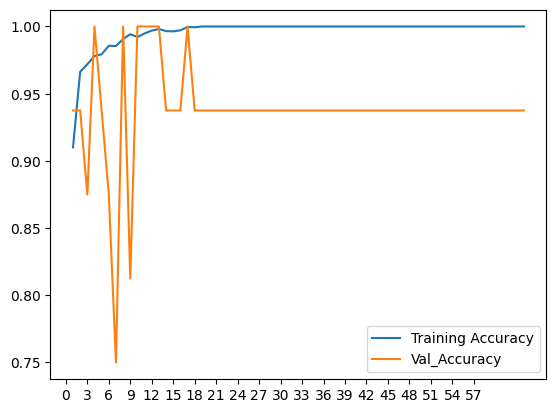

In [78]:
# Epoch List 
epoch_list = list(range(1, len(hist.history['accuracy']) +1))
plt.plot(epoch_list, hist.history['accuracy'], label='Training Accuracy')
plt.plot(epoch_list, hist.history['val_accuracy'], label='Val_Accuracy')
plt.xticks(range(0, 60, 3))
plt.legend()
plt.show()

Best epoch: 4


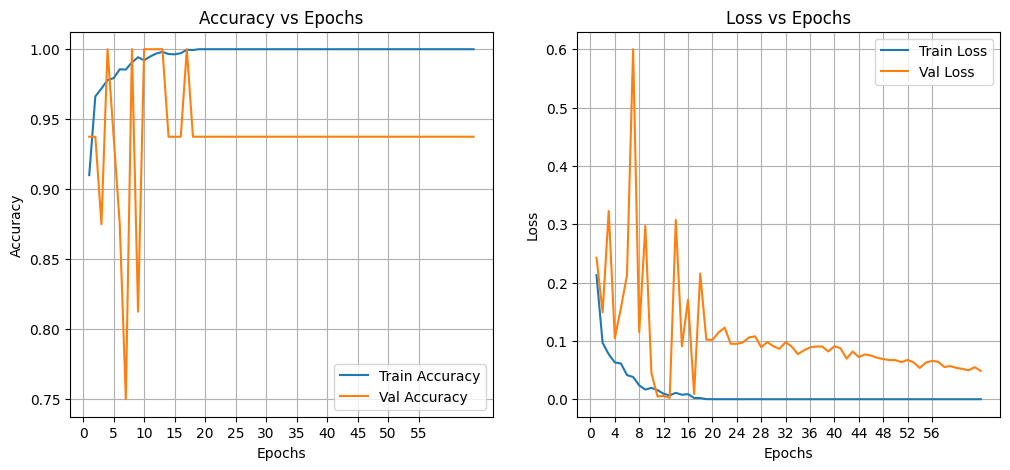

In [80]:
# Best Epoch
best_epoch = np.argmax(hist.history['val_accuracy'])
print("Best epoch:", best_epoch+1)

epoch_list = range(1, len(hist.history['accuracy']) + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)
plt.plot(epoch_list, hist.history['accuracy'], label='Train Accuracy')
plt.plot(epoch_list, hist.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy vs Epochs')
plt.grid()
plt.xticks(range(0, 60, 5))
plt.legend()

# Loss plot
plt.subplot(1,2,2)
plt.plot(epoch_list, hist.history['loss'], label='Train Loss')
plt.plot(epoch_list, hist.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid()
plt.title('Loss vs Epochs')
plt.xticks(range(0, 60, 4))

plt.legend()

plt.show()

In [9]:
# Improved model

model = Sequential()
model.add(Input(shape=(100, 100, 1)))

# Conv Block 1
model.add(Conv2D(filters=32, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

# Conv Block 2
model.add(Conv2D(filters=64, kernel_size=(3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

# Dense layers with L2 + Dropout
model.add(Dense(units=128, kernel_initializer='he_uniform', bias_initializer='zeros',
                activation='relu', kernel_regularizer=l2(0.001)))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(units=64, kernel_initializer='he_uniform', bias_initializer='zeros',
                activation='relu', kernel_regularizer=l2(0.001)))
model.add(Dropout(0.3))

model.add(Dense(units=1, kernel_initializer='he_uniform', bias_initializer='zeros',
                activation='sigmoid'))

# Lower LR from default 1e-3 to 1e-4
model.compile(
    loss='binary_crossentropy',
    optimizer=Adam(learning_rate=1e-4),
    metrics=['accuracy']
)

# --- Callbacks ---
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,  # auto-loads best epoch weights
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,         # halve the LR when stuck
    patience=5,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

